In [48]:
import numpy as np
import napari
import pathlib
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks, find_peaks_cwt
from skimage.filters import threshold_otsu, sobel, threshold_multiotsu, threshold_yen, threshold_li, threshold_triangle, gaussian
from skimage.feature import canny
from skimage.segmentation import watershed
from skimage.color import label2rgb
import scipy as sp
from skimage.measure import marching_cubes
import open3d as o3d
import skimage.measure as measure
from skimage.segmentation import find_boundaries
from skimage.morphology import binary_erosion, ball, disk, remove_small_objects

In [6]:
image_files = sorted(pathlib.Path('images/').glob('*.tif'), key=lambda x: int(x.stem.split('_')[-1]))
images = np.concatenate([io.imread(str(f))[None,...] for f in image_files])

In [54]:
binary_images = [ measure.label(img > threshold_multiotsu(img, classes=4)[0]) for img in images]
#binary_images = images > threshold_multiotsu(images, classes=4)[0]
labelled_images = [ remove_small_objects(measure.label(binary_images[idx]), min_size=512) for idx in range(len(images))]

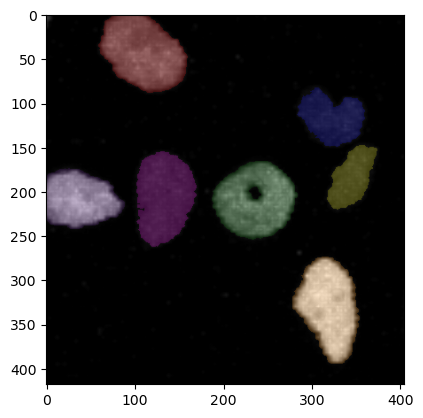

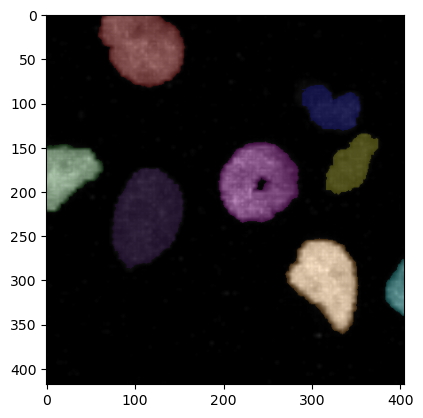

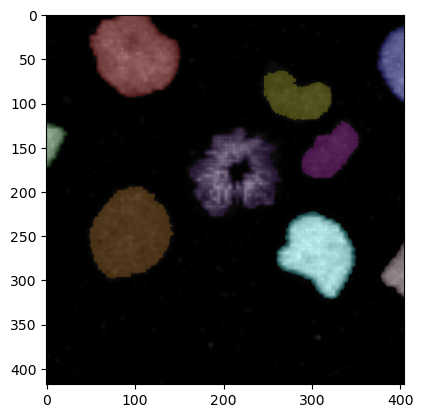

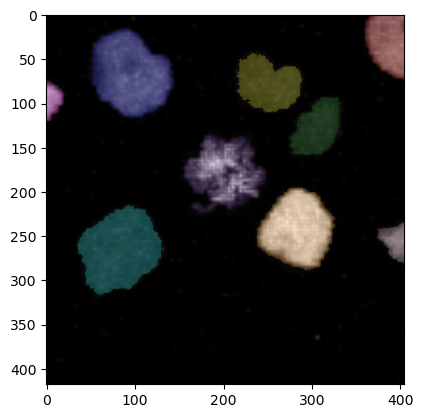

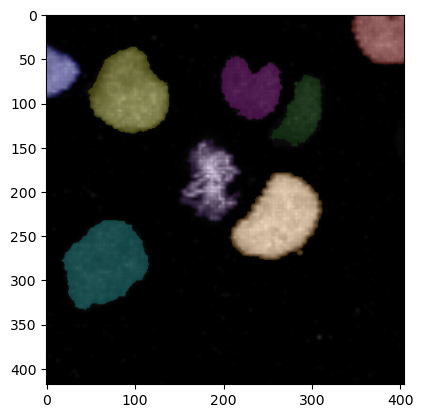

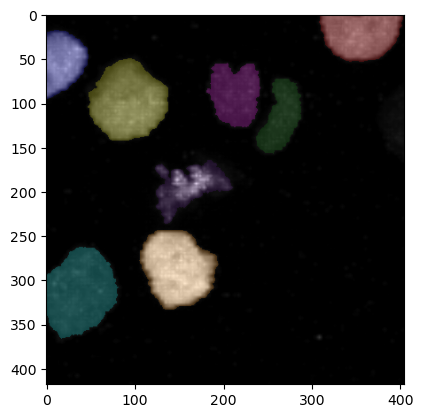

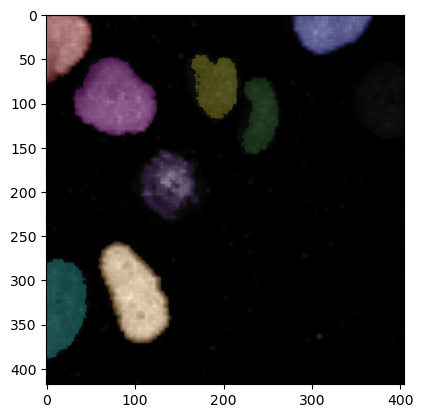

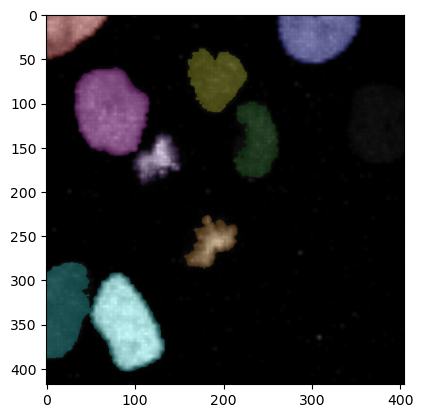

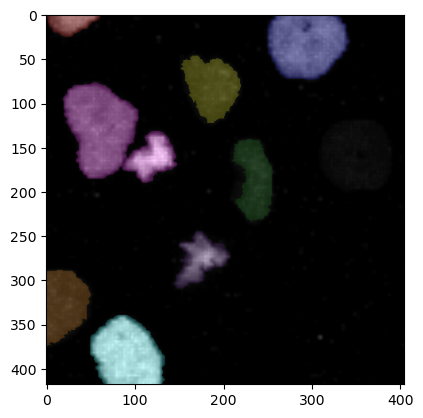

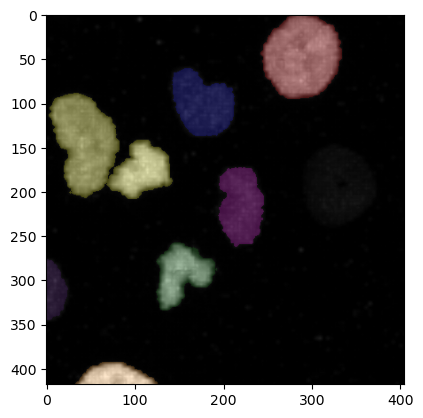

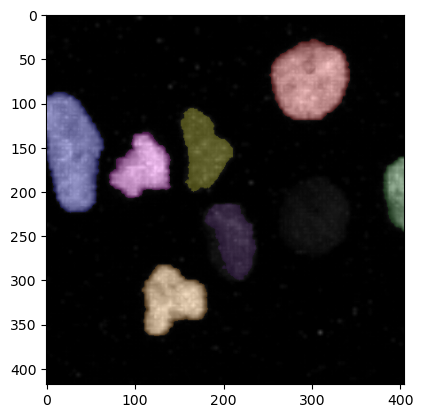

In [55]:
for idx in range(len(images)):
    plt.imshow(images[idx], cmap='gray')
    plt.imshow(label2rgb(labelled_images[idx]), alpha=0.2)
    plt.show()

In [ ]:
viewer = napari.Viewer()
viewer.add_image(images, name='raw')